<a href="https://colab.research.google.com/github/Dragonfly12347/Dragonfly12347/blob/main/Credit_Card_Fraud_Detection2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset Shape: (246600, 122)

First 5 rows:
    SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMEN

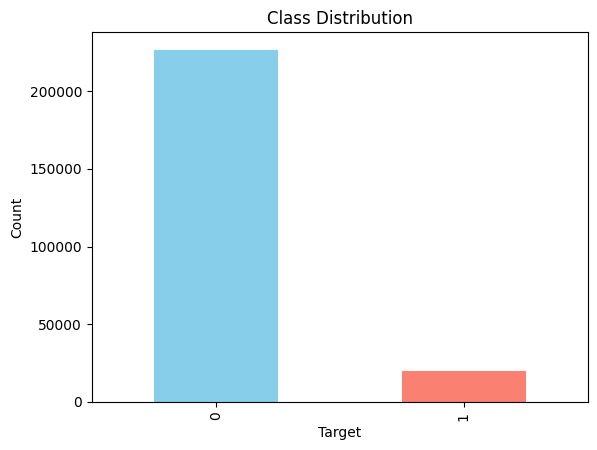

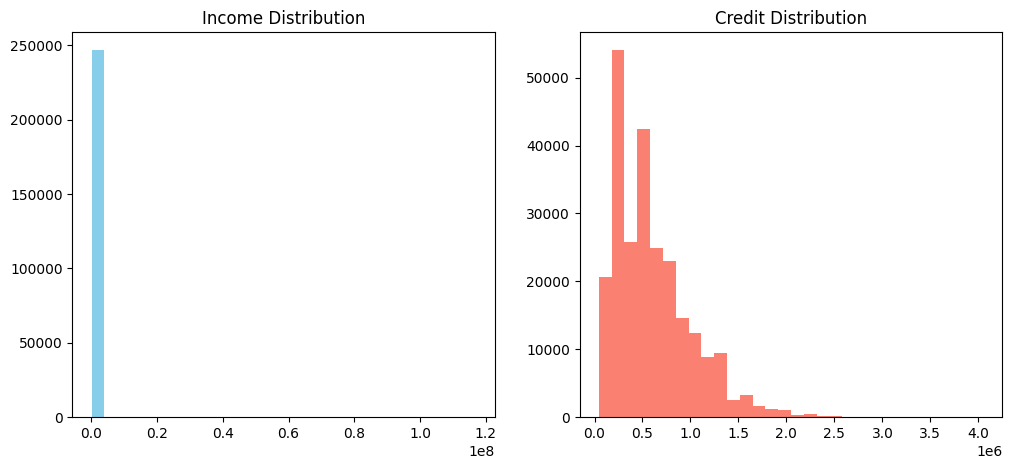

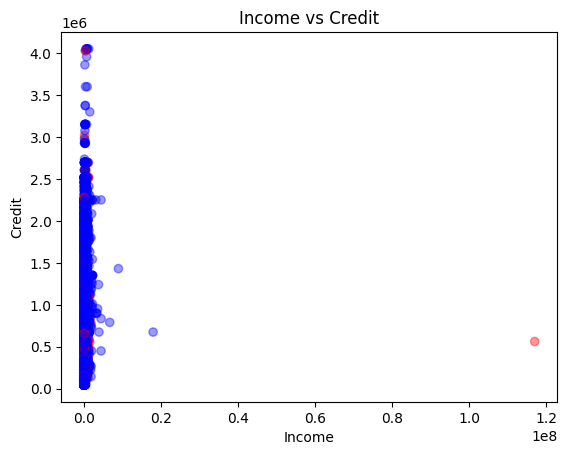

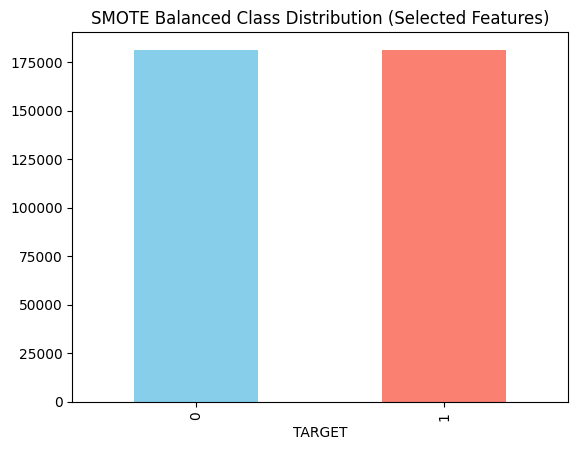


Selected Features Models


Selected Features - KNN Accuracy: 0.7483, F1 Score: 0.1378

Selected Features - KNN Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.79      0.85     45321
           1       0.10      0.25      0.14      3999

    accuracy                           0.75     49320
   macro avg       0.51      0.52      0.50     49320
weighted avg       0.86      0.75      0.79     49320



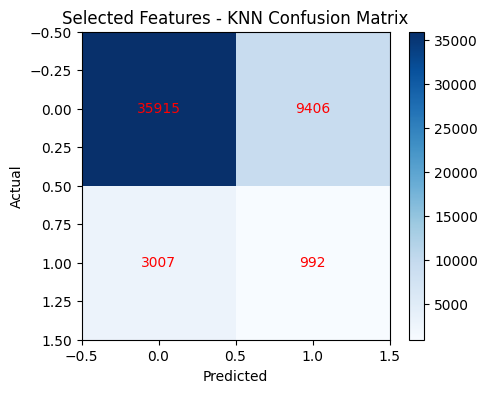


Selected Features - Decision Tree Accuracy: 0.8071, F1 Score: 0.1505

Selected Features - Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.86      0.89     45321
           1       0.12      0.21      0.15      3999

    accuracy                           0.81     49320
   macro avg       0.52      0.54      0.52     49320
weighted avg       0.86      0.81      0.83     49320



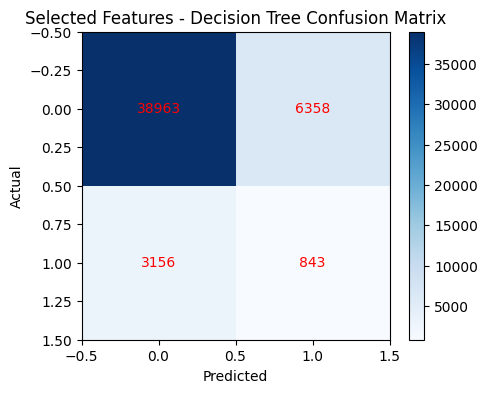


Selected Features - Random Forest Accuracy: 0.8260, F1 Score: 0.1537

Selected Features - Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.88      0.90     45321
           1       0.13      0.19      0.15      3999

    accuracy                           0.83     49320
   macro avg       0.53      0.54      0.53     49320
weighted avg       0.86      0.83      0.84     49320



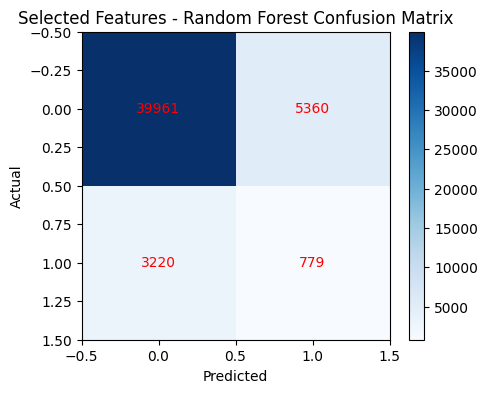


Selected Features - Logistic Regression Accuracy: 0.4827, F1 Score: 0.1665

Selected Features - Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.47      0.62     45321
           1       0.10      0.64      0.17      3999

    accuracy                           0.48     49320
   macro avg       0.52      0.55      0.40     49320
weighted avg       0.87      0.48      0.59     49320



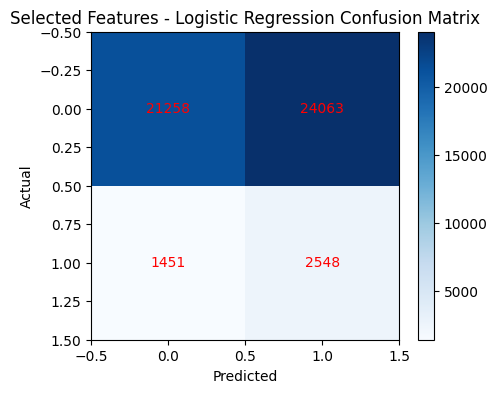

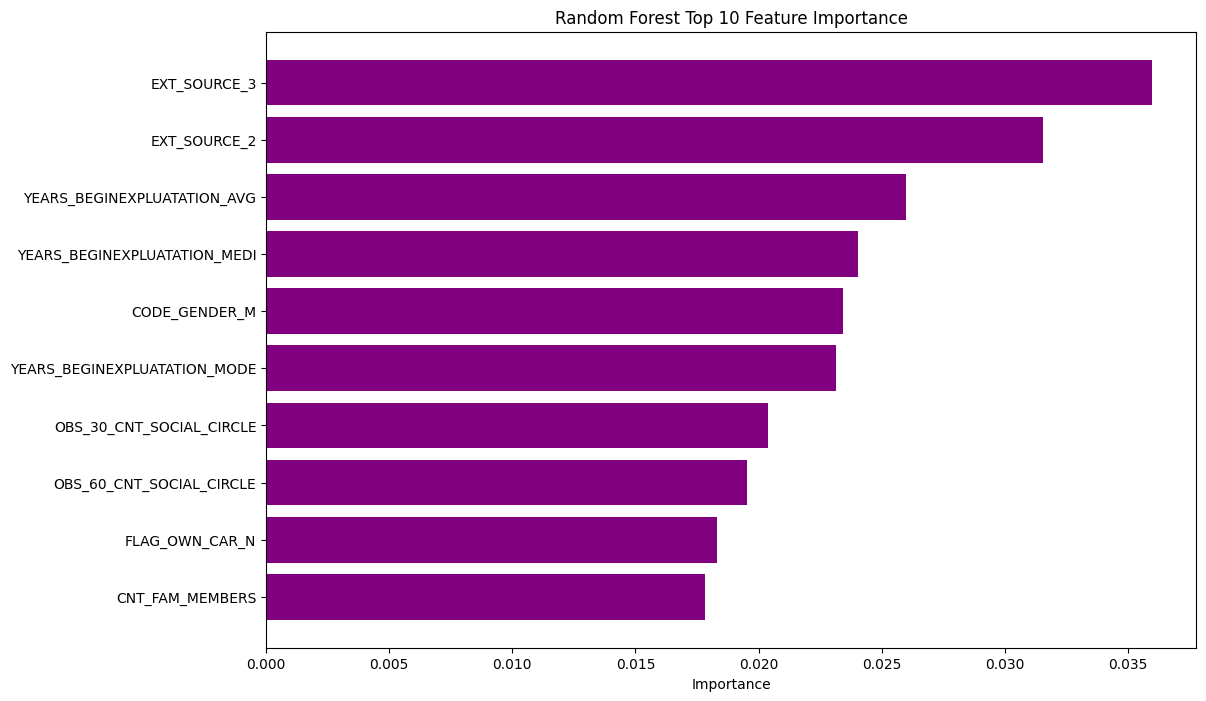


MLP Accuracy: 0.5928, F1 Score: 0.1908

MLP (Selected Features) Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.59      0.73     45321
           1       0.11      0.59      0.19      3999

    accuracy                           0.59     49320
   macro avg       0.53      0.59      0.46     49320
weighted avg       0.88      0.59      0.68     49320



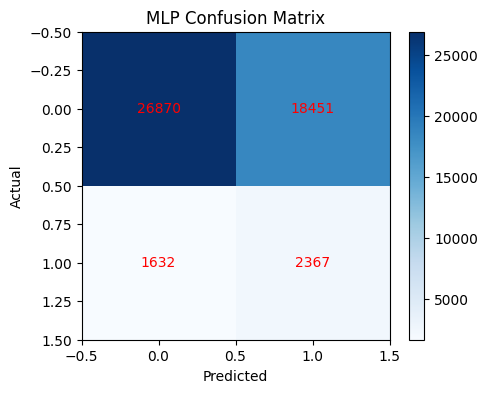

Epoch 1/3, Loss: 0.7242
Epoch 2/3, Loss: 0.6988
Epoch 3/3, Loss: 0.6497

CNN Accuracy: 0.5669, F1 Score: 0.1801

CNN (Selected Features) Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.57      0.71     45321
           1       0.11      0.59      0.18      3999

    accuracy                           0.57     49320
   macro avg       0.52      0.58      0.44     49320
weighted avg       0.87      0.57      0.66     49320



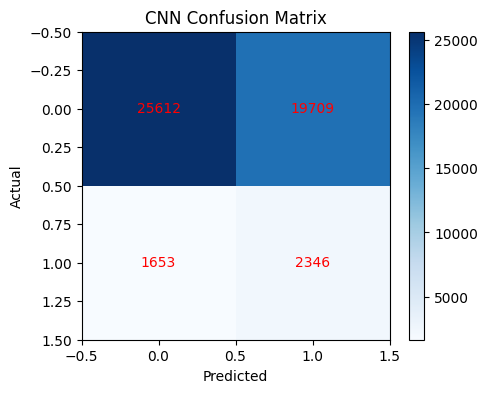


Model Performance (Accuracy & F1 Score):

                     Accuracy  F1 Score
KNN                  0.748317  0.137806
Decision Tree        0.807097  0.150536
Random Forest        0.826034  0.153679
Logistic Regression  0.482685  0.166482
MLP                  0.592802  0.190756
CNN                  0.566869  0.180088


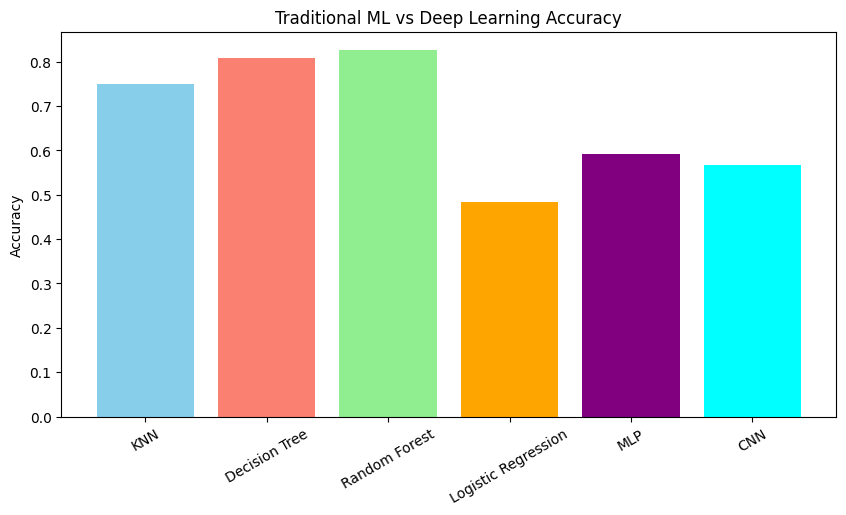

In [1]:
#===============================
# Credit Card Fraud Detection
# application.csv
#===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

#===============================
# Load Dataset
#===============================
df = pd.read_csv("application_data.csv")
df = df.ffillna(method='ffil')

# Print dataset shape and first 5 rows
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:\n", df.head())

#===============================
# EDA
#===============================
plt.figure()
df["TARGET"].value_counts().plot(kind="bar", color=['skyblue','salmon'])
plt.title("Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df["AMT_INCOME_TOTAL"], bins=30, color='skyblue')
plt.title("Income Distribution")
plt.subplot(1,2,2)
plt.hist(df["AMT_CREDIT"], bins=30, color='salmon')
plt.title("Credit Distribution")
plt.show()

plt.figure()
plt.scatter(df["AMT_INCOME_TOTAL"], df["AMT_CREDIT"], c=df["TARGET"], alpha=0.4, cmap='bwr')
plt.xlabel("Income")
plt.ylabel("Credit")
plt.title("Income vs Credit")
plt.show()

#===============================
# Feature Sets
#===============================
selected_features = ["AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE"]
X_selected = df[selected_features]
y = df["TARGET"]

#===============================
# Train-Test Split + SMOTE
#===============================
def split_scale_smote(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test

X_train_sel_scaled, X_test_sel_scaled, y_train_sel, y_test_sel = split_scale_smote(X_selected, y)

plt.figure()
pd.Series(y_train_sel).value_counts().plot(kind="bar", color=['skyblue','salmon'])
plt.title("SMOTE Balanced Class Distribution (Selected Features)")
plt.show()

#===============================
# Traditional ML Models
#===============================
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

def train_evaluate_models(models, X_train, X_test, y_train, y_test, title):
    results_acc = {}
    results_f1 = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred)
        results_acc[name] = acc
        results_f1[name] = f1

        # Print accuracy and f1
        print(f"\n{title} - {name} Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

        # Classification report
        print(f"\n{title} - {name} Classification Report:\n")
        print(classification_report(y_test, pred))

        # Confusion matrix
        cm = confusion_matrix(y_test, pred)
        plt.figure(figsize=(5,4))
        plt.imshow(cm, cmap='Blues')
        plt.title(f"{title} - {name} Confusion Matrix")
        plt.colorbar()
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
    return results_acc, results_f1

print("\nSelected Features Models\n")
acc_sel, f1_sel = train_evaluate_models(models, X_train_sel_scaled, X_test_sel_scaled, y_train_sel, y_test_sel, "Selected Features")

#===============================
# Random Forest Feature Importance (Top 10)
#===============================
X_all = df.drop("TARGET", axis=1)
X_all_encoded = pd.get_dummies(X_all)

X_train_all_scaled, X_test_all_scaled, y_train_all, y_test_all = split_scale_smote(X_all_encoded, y)

rf_all = RandomForestClassifier(n_estimators=200, random_state=42)
rf_all.fit(X_train_all_scaled, y_train_all)

importances_all = rf_all.feature_importances_
features_all = X_all_encoded.columns

imp_df_all = pd.DataFrame({"Feature": features_all, "Importance": importances_all})
imp_df_all = imp_df_all.sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(12,8))
plt.barh(imp_df_all["Feature"], imp_df_all["Importance"], color='purple')
plt.gca().invert_yaxis()
plt.title("Random Forest Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

#===============================
# Deep Learning: MLP
#===============================
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, early_stopping=True, random_state=42)
mlp.fit(X_train_sel_scaled, y_train_sel)
pred_mlp = mlp.predict(X_test_sel_scaled)
mlp_acc = accuracy_score(y_test_sel, pred_mlp)
mlp_f1 = f1_score(y_test_sel, pred_mlp)

print(f"\nMLP Accuracy: {mlp_acc:.4f}, F1 Score: {mlp_f1:.4f}")
print("\nMLP (Selected Features) Classification Report:\n")
print(classification_report(y_test_sel, pred_mlp))
cm = confusion_matrix(y_test_sel, pred_mlp)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#===============================
# Deep Learning: CNN
#===============================
X_train_cnn = torch.tensor(X_train_sel_scaled, dtype=torch.float32).unsqueeze(1)
X_test_cnn = torch.tensor(X_test_sel_scaled, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train_sel.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test_sel.values, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_cnn, y_train_t), batch_size=128, shuffle=True)

class CNN(nn.Module):
    def __init__(self,input_size):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv1d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.fc=nn.Sequential(
            nn.Flatten(),
            nn.Linear((input_size//4)*32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self,x):
        x=self.conv(x)
        x=self.fc(x)
        return x.squeeze()

cnn_model = CNN(X_train_sel_scaled.shape[1])
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

# CNN Training loop - fewer epochs
epochs = 3
for epoch in range(epochs):
    cnn_model.train()
    for xb, yb in train_loader:
        pred = cnn_model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# Evaluate CNN
cnn_model.eval()
with torch.no_grad():
    y_pred_cnn = torch.sigmoid(cnn_model(X_test_cnn)).round()
    cnn_acc = accuracy_score(y_test_sel, y_pred_cnn)
    cnn_f1 = f1_score(y_test_sel, y_pred_cnn)
    print(f"\nCNN Accuracy: {cnn_acc:.4f}, F1 Score: {cnn_f1:.4f}")
    print("\nCNN (Selected Features) Classification Report:\n")
    print(classification_report(y_test_sel, y_pred_cnn))
    cm = confusion_matrix(y_test_sel, y_pred_cnn)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap='Blues')
    plt.title("CNN Confusion Matrix")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

#===============================
# Accuracy & F1 Comparison Table
#===============================
all_results = {
    "KNN": (acc_sel["KNN"], f1_sel["KNN"]),
    "Decision Tree": (acc_sel["Decision Tree"], f1_sel["Decision Tree"]),
    "Random Forest": (acc_sel["Random Forest"], f1_sel["Random Forest"]),
    "Logistic Regression": (acc_sel["Logistic Regression"], f1_sel["Logistic Regression"]),
    "MLP": (mlp_acc, mlp_f1),
    "CNN": (cnn_acc, cnn_f1)
}

results_df = pd.DataFrame(all_results, index=["Accuracy", "F1 Score"]).T
print("\nModel Performance (Accuracy & F1 Score):\n")
print(results_df)

# Plot Accuracy Comparison
plt.figure(figsize=(10,5))
colors = ['skyblue','salmon','lightgreen','orange','purple','cyan']
plt.bar(results_df.index, results_df["Accuracy"], color=colors)
plt.ylabel("Accuracy")
plt.title("Traditional ML vs Deep Learning Accuracy")
plt.xticks(rotation=30)
plt.show()